# A/B-тест новой посадочной страницы e-commerce

## Описание проекта

В этом проекте анализируются результаты A/B-теста новой посадочной страницы интернет-магазина.

Часть пользователей попала в контрольную группу и видела старую версию страницы, а часть пользователей попала в тестовую группу и видела новую версию страницы.

Цель проекта — проверить, улучшила ли новая страница ключевые продуктовые и денежные метрики:

- conversion rate;
- ARPU;
- average check.

Анализ включает проверку качества данных, исследовательский анализ, расчёт метрик, статистические тесты, доверительные интервалы и итоговую бизнес-рекомендацию.

## Данные

В проекте используется учебный датасет с Kaggle: **A/B Testing**.

Датасет содержит информацию о пользователях e-commerce сайта, участвовавших в A/B-тесте новой посадочной страницы.

Основные колонки:

- `user_id` — идентификатор пользователя;
- `timestamp` — время события;
- `group` — экспериментальная группа пользователя;
- `landing_page` — версия посадочной страницы;
- `converted` — факт совершения покупки;
- `purchase_amount` — сумма покупки;
- `age` — возраст пользователя;
- `gender` — пол пользователя;
- `location` — страна пользователя;
- `session_duration` — длительность сессии;
- `pages_visited` — количество просмотренных страниц;
- `device_type` — тип устройства.

Датасет позволяет оценить влияние новой посадочной страницы на conversion rate, ARPU и average check.

## 1. Импорт библиотек

На этом этапе импортируем библиотеки для загрузки и обработки данных, визуализации, статистических тестов и расчёта доверительных интервалов.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats as sts
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

## 2. Загрузка данных

Загрузим датасет и посмотрим на его структуру: количество строк и столбцов, названия колонок, типы данных и первые записи.

In [6]:
df = pd.read_csv('AB Testing Data.csv')

df.head()

,user_id,timestamp,group,landing_page,converted,age,gender,location,session_duration,pages_visited,device_type,purchase_amount
0,U1,2025-08-02 15:27:54.137058,control,old_page,0,37,Male,Pakistan,3.69,4,Mobile,0.0
1,U2,2024-04-22 10:22:51.712050,treatment,new_page,0,31,Female,UK,1.29,3,Desktop,0.0
2,U3,2024-08-14 21:35:11.135894,treatment,new_page,0,38,Male,US,3.72,5,Desktop,0.0
3,U4,2025-03-19 03:28:51.120807,treatment,new_page,0,28,Female,India,7.76,2,Mobile,0.0
4,U5,2024-12-22 13:13:17.973162,control,old_page,0,33,Male,Australia,6.78,6,Mobile,0.0


In [7]:
df.shape

(294478, 12)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   user_id           294478 non-null  str    
 1   timestamp         294478 non-null  str    
 2   group             294478 non-null  str    
 3   landing_page      294478 non-null  str    
 4   converted         294478 non-null  int64  
 5   age               294478 non-null  int64  
 6   gender            294478 non-null  str    
 7   location          294478 non-null  str    
 8   session_duration  294478 non-null  float64
 9   pages_visited     294478 non-null  int64  
 10  device_type       294478 non-null  str    
 11  purchase_amount   294478 non-null  float64
dtypes: float64(2), int64(3), str(7)
memory usage: 19.1 MB


In [9]:
df.describe()

,converted,age,session_duration,pages_visited,purchase_amount
count,294478.000000,294478.000000,294478.000000,294478.000000,294478.000000
mean,0.149172,31.902084,5.002136,4.019550,5.610490
std,0.356259,9.250043,1.980285,1.965182,15.438006
min,0.000000,18.000000,0.500000,1.000000,0.000000
25%,0.000000,25.000000,3.640000,3.000000,0.000000
50%,0.000000,32.000000,4.990000,4.000000,0.000000
75%,0.000000,38.000000,6.340000,5.000000,0.000000
max,1.000000,65.000000,13.730000,18.000000,269.280000


## 3. Проверка качества данных

Перед анализом проверим датасет на возможные проблемы:

- пропуски;
- полные дубликаты строк;
- повторяющихся пользователей;
- пользователей, попавших в обе группы;
- корректность соответствия между `group` и `landing_page`;
- уникальные значения категориальных признаков.

In [19]:
df.isna().sum()

user_id             0
timestamp           0
group               0
landing_page        0
converted           0
age                 0
gender              0
location            0
session_duration    0
pages_visited       0
device_type         0
purchase_amount     0
dtype: int64

**Вывод:** пропущенных значений в датасете нет. Все колонки заполнены для всех 294478 строк, поэтому дополнительная обработка пропусков не требуется.

In [12]:
print(df.duplicated().sum())

0


**Вывод:** полных дубликатов строк не обнаружено. Это значит, что в датасете нет полностью повторяющихся записей.

In [13]:
print('Количество строк:', df.shape[0])
print('Количество уникальных пользователей:', df['user_id'].nunique())
print('Количество повторяющихся user_id:', df.shape[0] - df['user_id'].nunique())

Количество строк: 294478
Количество уникальных пользователей: 294478
Количество повторяющихся user_id: 0


**Вывод:** количество строк совпадает с количеством уникальных пользователей. Каждый пользователь встречается в датасете ровно один раз, поэтому дополнительная агрегация на уровне пользователя не требуется.

In [14]:
users_in_groups = df.groupby('user_id')['group'].nunique()

users_in_multiple_groups = users_in_groups[users_in_groups > 1]

users_in_multiple_groups.shape[0]

0

**Вывод:** пользователей, попавших одновременно в несколько экспериментальных групп, не обнаружено. Это значит, что разбиение пользователей между control и treatment выполнено корректно.

In [15]:
pd.crosstab(df['group'], df['landing_page'])

landing_page,new_page,old_page
group,,
control,0,146926
treatment,147552,0


**Вывод:** соответствие между экспериментальной группой и типом посадочной страницы корректное: пользователи из `control` видели `old_page`, а пользователи из `treatment` видели `new_page`. Некорректных сочетаний групп и страниц не обнаружено.

In [21]:
categorical_columns = ['group', 'landing_page', 'gender', 'location', 'device_type']

for col in categorical_columns:
    print(f'{col}:')
    print(df[col].value_counts())
    print()

group:
group
treatment    147552
control      146926
Name: count, dtype: int64

landing_page:
landing_page
new_page    147552
old_page    146926
Name: count, dtype: int64

gender:
gender
Male      144708
Female    143785
Other       5985
Name: count, dtype: int64

location:
location
US           88342
India        59014
UK           44217
Pakistan     29600
Germany      29477
Canada       29241
Australia    14587
Name: count, dtype: int64

device_type:
device_type
Desktop    176692
Mobile     103093
Tablet      14693
Name: count, dtype: int64



**Вывод:** категориальные признаки выглядят корректно. В датасете есть две экспериментальные группы (`control` и `treatment`), две версии страницы (`old_page` и `new_page`), а также дополнительные признаки пользователей: пол, страна и тип устройства.

Размеры групп близки друг к другу: в тестовой группе 147552 пользователя, в контрольной — 146926 пользователей. Это хороший признак для A/B-теста, так как группы получились примерно одинаковыми по размеру.

In [17]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['timestamp'].dtype

dtype('<M8[us]')

In [23]:
print('Начало эксперимента:', df['timestamp'].min())
print('Конец эксперимента:', df['timestamp'].max())

Начало эксперимента: 2023-08-30 22:23:34.584307
Конец эксперимента: 2025-08-30 09:48:09.479117


**Вывод:** колонка `timestamp` успешно преобразована в формат даты и времени. Данные охватывают период с 30 августа 2023 года по 30 августа 2025 года.

Так как датасет учебный, длительный период наблюдений не будем интерпретировать как реальную продолжительность одного A/B-теста. В дальнейшем используем временной признак для общего понимания структуры данных.

### Итог по качеству данных

Данные готовы к дальнейшему анализу:

- пропущенные значения отсутствуют;
- полные дубликаты строк отсутствуют;
- каждый пользователь встречается в датасете один раз;
- пользователей, попавших одновременно в несколько групп, нет;
- соответствие между `group` и `landing_page` корректное;
- размеры групп примерно сбалансированы.

На следующем этапе можно перейти к EDA и расчёту основных метрик A/B-теста.

## 4. Подготовка данных для анализа

Перед EDA создадим несколько дополнительных признаков:

- `is_purchase` — факт покупки на основе `purchase_amount`;
- `date` — дата события без времени;
- `revenue` — выручка пользователя.

Также проверим, совпадает ли колонка `converted` с фактом положительной покупки.

In [24]:
df['is_purchase'] = df['purchase_amount'] > 0
df['date'] = df['timestamp'].dt.date
df['revenue'] = df['purchase_amount']
df.head()

,user_id,timestamp,group,landing_page,converted,age,gender,location,session_duration,pages_visited,device_type,purchase_amount,is_purchase,date,revenue
0,U1,2025-08-02 15:27:54.137058,control,old_page,0,37,Male,Pakistan,3.69,4,Mobile,0.0,False,2025-08-02,0.0
1,U2,2024-04-22 10:22:51.712050,treatment,new_page,0,31,Female,UK,1.29,3,Desktop,0.0,False,2024-04-22,0.0
2,U3,2024-08-14 21:35:11.135894,treatment,new_page,0,38,Male,US,3.72,5,Desktop,0.0,False,2024-08-14,0.0
3,U4,2025-03-19 03:28:51.120807,treatment,new_page,0,28,Female,India,7.76,2,Mobile,0.0,False,2025-03-19,0.0
4,U5,2024-12-22 13:13:17.973162,control,old_page,0,33,Male,Australia,6.78,6,Mobile,0.0,False,2024-12-22,0.0


In [25]:
pd.crosstab(df['converted'], df['is_purchase'])

is_purchase,False,True
converted,,
0,250550,0
1,0,43928


**Вывод:** колонка `converted` согласуется с фактом покупки: пользователи с `converted = 1` имеют положительный `purchase_amount`, а пользователи с `converted = 0` не совершили покупку. Поэтому `converted` можно использовать для расчёта conversion rate, а `purchase_amount` — для денежных метрик.

## 5. Исследовательский анализ данных

Начнём с проверки размеров экспериментальных групп. Для A/B-теста важно, чтобы группы были примерно сопоставимы по количеству пользователей.

In [26]:
group_sizes = df['group'].value_counts()
group_sizes

group
treatment    147552
control      146926
Name: count, dtype: int64

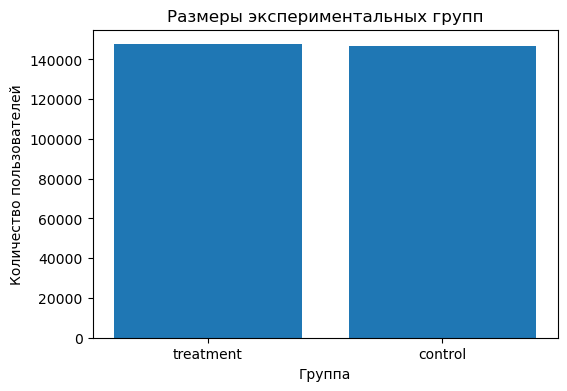

In [27]:
plt.figure(figsize=(6, 4))
plt.bar(group_sizes.index, group_sizes.values)
plt.title('Размеры экспериментальных групп')
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')
plt.show()

**Вывод:** размеры групп близки друг к другу: в контрольной группе 146926 пользователей, в тестовой — 147552 пользователя. Такое распределение выглядит достаточно сбалансированным для дальнейшего анализа A/B-теста.

## 6. Расчёт основных метрик

Рассчитаем ключевые метрики отдельно для контрольной и тестовой групп:

- **conversion rate** — доля пользователей, совершивших покупку;
- **ARPU** — средняя выручка на одного пользователя;
- **average check** — средний чек среди пользователей, совершивших покупку.

In [29]:
metrics = (
    df
    .groupby('group')
    .agg(
        users=('user_id', 'nunique'),
        conversions=('converted', 'sum'),
        conversion_rate=('converted', 'mean'),
        total_revenue=('revenue', 'sum'),
        arpu=('revenue', 'mean'),
        average_check=('revenue', lambda x: x[x > 0].mean())
    )
    .reset_index()
)
metrics

,group,users,conversions,conversion_rate,total_revenue,arpu,average_check
0,control,146926,17444,0.118726,654227.55,4.452769,37.504446
1,treatment,147552,26484,0.179489,997938.36,6.763299,37.680802


In [30]:
metrics_formatted = metrics.copy()
metrics_formatted['conversion_rate'] = metrics_formatted['conversion_rate'].map('{:.2%}'.format)
metrics_formatted['total_revenue'] = metrics_formatted['total_revenue'].map('{:.2f}'.format)
metrics_formatted['arpu'] = metrics_formatted['arpu'].map('{:.2f}'.format)
metrics_formatted['average_check'] = metrics_formatted['average_check'].map('{:.2f}'.format)

metrics_formatted

,group,users,conversions,conversion_rate,total_revenue,arpu,average_check
0,control,146926,17444,11.87%,654227.55,4.45,37.50
1,treatment,147552,26484,17.95%,997938.36,6.76,37.68


In [31]:
control = metrics[metrics['group'] == 'control'].iloc[0]
treatment = metrics[metrics['group'] == 'treatment'].iloc[0]

conversion_uplift = treatment['conversion_rate'] / control['conversion_rate'] - 1
arpu_uplift = treatment['arpu'] / control['arpu'] - 1
avg_check_uplift = treatment['average_check'] / control['average_check'] - 1

print(f"Conversion rate uplift: {conversion_uplift:.2%}")
print(f"ARPU uplift: {arpu_uplift:.2%}")
print(f"Average check uplift: {avg_check_uplift:.2%}")

Conversion rate uplift: 51.18%
ARPU uplift: 51.89%
Average check uplift: 0.47%


In [34]:
conversion_abs_diff = treatment['conversion_rate'] - control['conversion_rate']
arpu_abs_diff = treatment['arpu'] - control['arpu']
avg_check_abs_diff = treatment['average_check'] - control['average_check']

print(f"Conversion rate absolute difference: {conversion_abs_diff:.2%}")
print(f"ARPU absolute difference: {arpu_abs_diff:.2f}")
print(f"Average check absolute difference: {avg_check_abs_diff:.2f}")

Conversion rate absolute difference: 6.08%
ARPU absolute difference: 2.31
Average check absolute difference: 0.18


**Промежуточный вывод:** тестовая группа показывает более высокие значения conversion rate и ARPU по сравнению с контрольной группой.

Конверсия выросла с 11.87% до 17.95%, то есть на 6.08 процентного пункта. В относительном выражении uplift составил около 51.18%.

ARPU вырос с 4.45 до 6.76, относительный uplift составил около 51.89%.

Average check почти не изменился: рост составил около 0.47%. Это может означать, что новая страница влияет скорее на вероятность покупки, чем на размер заказа.

Однако на этом этапе нельзя делать финальный вывод об эффективности новой страницы: необходимо проверить, являются ли различия статистически значимыми.

## 7. Визуализация основных метрик

Построим графики для сравнения ключевых метрик между контрольной и тестовой группами.

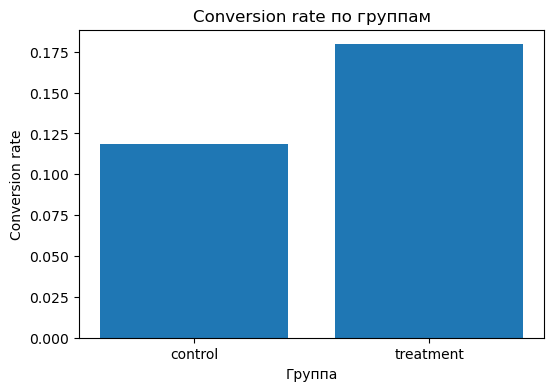

In [36]:
plt.figure(figsize=(6, 4))
plt.bar(metrics['group'], metrics['conversion_rate'])
plt.title('Conversion rate по группам')
plt.xlabel('Группа')
plt.ylabel('Conversion rate')

plt.show()

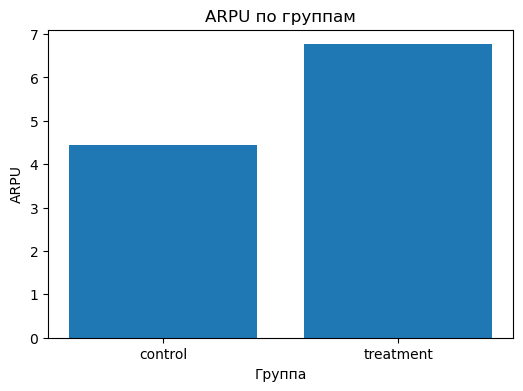

In [37]:
plt.figure(figsize=(6, 4))
plt.bar(metrics['group'], metrics['arpu'])
plt.title('ARPU по группам')
plt.xlabel('Группа')
plt.ylabel('ARPU')

plt.show()

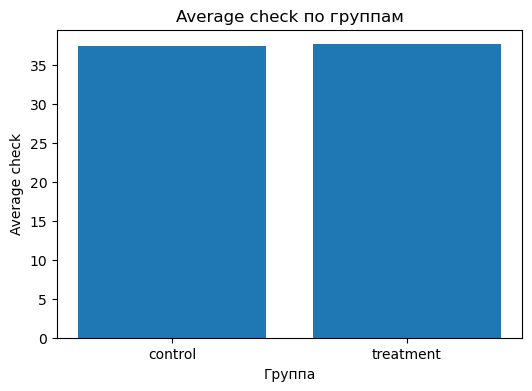

In [38]:
plt.figure(figsize=(6, 4))
plt.bar(metrics['group'], metrics['average_check'])
plt.title('Average check по группам')
plt.xlabel('Группа')
plt.ylabel('Average check')

plt.show()

**Вывод:** визуально видно, что тестовая группа заметно превосходит контрольную по conversion rate и ARPU. При этом average check практически не отличается между группами. Это подтверждает предварительную гипотезу: новая страница может увеличивать вероятность покупки, но не размер среднего заказа.

## 8. Статистическая проверка conversion rate

На предыдущем этапе мы увидели, что conversion rate в тестовой группе выше, чем в контрольной. Теперь проверим, является ли это различие статистически значимым.

Для сравнения конверсий используем z-test для двух пропорций.

Гипотезы:

- $H_0$: conversion rate в контрольной и тестовой группах не отличается;
- $H_1$: conversion rate в контрольной и тестовой группах отличается.

Уровень значимости: $\alpha = 0.05$.

In [39]:
conversion_data = (
    df
    .groupby('group')
    .agg(
        users=('user_id', 'nunique'),
        conversions=('converted', 'sum'),
        conversion_rate=('converted', 'mean')
    )
)
conversion_data

,users,conversions,conversion_rate
group,,,
control,146926,17444,0.118726
treatment,147552,26484,0.179489


In [43]:
alpha = 0.05

count = np.array([
    conversion_data.loc['control', 'conversions'],
    conversion_data.loc['treatment', 'conversions']
])

nobs = np.array([
    conversion_data.loc['control', 'users'],
    conversion_data.loc['treatment', 'users']
])

z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative='two-sided'
)

print(f'z-statistic: {z_stat:.4f}')
print(f'p-value: {p_value:.2e}')

z-statistic: -46.2773
p-value: 0.00e+00


In [41]:
if p_value < alpha:
    print('Отвергаем H0: различие conversion rate между группами статистически значимо.')
else:
    print('Не отвергаем H0: статистически значимого различия conversion rate между группами не обнаружено.')

Отвергаем H0: различие conversion rate между группами статистически значимо.


## 9. Доверительный интервал для разницы conversion rate

Кроме p-value рассчитаем 95% доверительный интервал для разницы conversion rate между тестовой и контрольной группами.

Если доверительный интервал не включает 0, это дополнительно подтверждает статистически значимое различие между группами.

In [42]:
control_conversions = conversion_data.loc['control', 'conversions']
control_users = conversion_data.loc['control', 'users']
control_cr = conversion_data.loc['control', 'conversion_rate']

treatment_conversions = conversion_data.loc['treatment', 'conversions']
treatment_users = conversion_data.loc['treatment', 'users']
treatment_cr = conversion_data.loc['treatment', 'conversion_rate']

cr_diff = treatment_cr - control_cr

se_diff = np.sqrt(
    control_cr * (1 - control_cr) / control_users +
    treatment_cr * (1 - treatment_cr) / treatment_users
)

z_critical = sts.norm.ppf(1 - alpha / 2)

ci_lower = cr_diff - z_critical * se_diff
ci_upper = cr_diff + z_critical * se_diff

print(f'Control conversion rate: {control_cr:.2%}')
print(f'Treatment conversion rate: {treatment_cr:.2%}')
print(f'Difference: {cr_diff:.2%}')
print(f'95% CI for difference: [{ci_lower:.2%}, {ci_upper:.2%}]')

Control conversion rate: 11.87%
Treatment conversion rate: 17.95%
Difference: 6.08%
95% CI for difference: [5.82%, 6.33%]


**Вывод:** z-test показал статистически значимое различие conversion rate между контрольной и тестовой группами.

Conversion rate вырос с 11.87% в контрольной группе до 17.95% в тестовой группе. Абсолютная разница составила около 6.08 процентного пункта.

95% доверительный интервал для разницы conversion rate не включает 0, поэтому можно сделать вывод, что новая посадочная страница статистически значимо увеличила конверсию.

## 10. Статистическая проверка ARPU

ARPU показывает среднюю выручку на одного пользователя, включая пользователей без покупки.

На предыдущем этапе ARPU в тестовой группе оказался выше, чем в контрольной. Теперь проверим, является ли это различие статистически значимым.

Для сравнения средних значений ARPU используем двухвыборочный t-test.

Гипотезы:

- $H_0$: средний ARPU в контрольной и тестовой группах не отличается;
- $H_1$: средний ARPU в контрольной и тестовой группах отличается.

Уровень значимости: $\alpha = 0.05$.

In [45]:
control_revenue = df[df['group'] == 'control']['revenue']
treatment_revenue = df[df['group'] == 'treatment']['revenue']

print(f'Control ARPU: {control_revenue.mean():.2f}')
print(f'Treatment ARPU: {treatment_revenue.mean():.2f}')
print(f'Difference: {treatment_revenue.mean() - control_revenue.mean():.2f}')

Control ARPU: 4.45
Treatment ARPU: 6.76
Difference: 2.31


In [50]:
t_stat, p_value_arpu = sts.ttest_ind(
    control_revenue,
    treatment_revenue,
    equal_var=False
)

print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_value_arpu:.2e}')

t-statistic: -40.7382
p-value: 0.00e+00


In [51]:
if p_value_arpu < alpha:
    print('Отвергаем H0: различие ARPU между группами статистически значимо.')
else:
    print('Не отвергаем H0: статистически значимого различия ARPU между группами не обнаружено.')

Отвергаем H0: различие ARPU между группами статистически значимо.


**Вывод:** ARPU в тестовой группе выше, чем в контрольной.

t-test показал статистически значимое различие между средними значениями ARPU в контрольной и тестовой группах. Это означает, что новая посадочная страница положительно повлияла на среднюю выручку на пользователя.

## 11. Статистическая проверка average check

Average check показывает среднюю сумму покупки среди пользователей, которые совершили покупку.

В отличие от ARPU, эта метрика считается только по покупателям, поэтому сначала оставим только пользователей с положительной выручкой.

Для сравнения среднего чека между контрольной и тестовой группами используем двухвыборочный t-test.

Гипотезы:

- $H_0$: средний чек в контрольной и тестовой группах не отличается;
- $H_1$: средний чек в контрольной и тестовой группах отличается.

Уровень значимости: $\alpha = 0.05$.

In [52]:
buyers = df[df['revenue'] > 0]

control_check = buyers[buyers['group'] == 'control']['revenue']
treatment_check = buyers[buyers['group'] == 'treatment']['revenue']

print(f'Control average check: {control_check.mean():.2f}')
print(f'Treatment average check: {treatment_check.mean():.2f}')
print(f'Difference: {treatment_check.mean() - control_check.mean():.2f}')

Control average check: 37.50
Treatment average check: 37.68
Difference: 0.18


In [53]:
t_stat, p_value_check = sts.ttest_ind(
    control_check,
    treatment_check,
    equal_var=False
)

print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_value_check:.2e}')

t-statistic: -0.9112
p-value: 3.62e-01


In [54]:
if p_value_check < alpha:
    print('Отвергаем H0: различие average check между группами статистически значимо.')
else:
    print('Не отвергаем H0: статистически значимого различия average check между группами не обнаружено.')

Не отвергаем H0: статистически значимого различия average check между группами не обнаружено.


**Вывод:** средний чек в тестовой группе почти не отличается от среднего чека в контрольной группе.

Средний чек в контрольной группе составляет 37.50, а в тестовой — 37.68. Разница равна 0.18.

p-value = 0.362, что больше уровня значимости 0.05. Поэтому мы не отвергаем нулевую гипотезу: статистически значимого различия average check между группами не обнаружено.

Это означает, что новая посадочная страница, скорее всего, повлияла не на размер покупки, а на вероятность совершения покупки. Основной эффект проявляется в росте conversion rate и ARPU.

## 12. Доверительные интервалы для ARPU и average check

Ранее мы проверили различия между группами с помощью статистических тестов. Теперь рассчитаем 95% доверительные интервалы для разницы средних значений.

Для ARPU интервал считается по всем пользователям, так как ARPU учитывает и покупателей, и пользователей без покупки.

Для average check интервал считается только по покупателям, так как средний чек определяется только среди пользователей с положительной выручкой.

In [56]:
def mean_diff_ci(control_values, treatment_values, alpha=0.05):
    control_values = np.array(control_values)
    treatment_values = np.array(treatment_values)
    
    control_mean = control_values.mean()
    treatment_mean = treatment_values.mean()
    
    diff = treatment_mean - control_mean
    
    control_var = control_values.var(ddof=1)
    treatment_var = treatment_values.var(ddof=1)
    
    control_n = len(control_values)
    treatment_n = len(treatment_values)
    
    se = np.sqrt(control_var / control_n + treatment_var / treatment_n)
    
    df_num = (control_var / control_n + treatment_var / treatment_n) ** 2
    df_den = (
        (control_var / control_n) ** 2 / (control_n - 1) +
        (treatment_var / treatment_n) ** 2 / (treatment_n - 1)
    )
    degrees_of_freedom = df_num / df_den
    
    t_critical = sts.t.ppf(1 - alpha / 2, degrees_of_freedom)
    
    ci_lower = diff - t_critical * se
    ci_upper = diff + t_critical * se
    
    return diff, ci_lower, ci_upper

In [57]:
arpu_diff, arpu_ci_lower, arpu_ci_upper = mean_diff_ci(
    control_revenue,
    treatment_revenue,
    alpha=alpha
)

print(f'ARPU difference: {arpu_diff:.2f}')
print(f'95% CI for ARPU difference: [{arpu_ci_lower:.2f}, {arpu_ci_upper:.2f}]')

ARPU difference: 2.31
95% CI for ARPU difference: [2.20, 2.42]


In [58]:
check_diff, check_ci_lower, check_ci_upper = mean_diff_ci(
    control_check,
    treatment_check,
    alpha=alpha
)

print(f'Average check difference: {check_diff:.2f}')
print(f'95% CI for average check difference: [{check_ci_lower:.2f}, {check_ci_upper:.2f}]')

Average check difference: 0.18
95% CI for average check difference: [-0.20, 0.56]


**Вывод:** доверительный интервал для разницы ARPU не включает 0, что согласуется с результатом t-test: ARPU в тестовой группе статистически значимо выше.

Доверительный интервал для разницы average check включает 0, что согласуется с результатом t-test: статистически значимого изменения среднего чека не обнаружено.

## 13. Итоговая таблица результатов

Соберём основные результаты A/B-теста в одну таблицу: значения метрик в контрольной и тестовой группах, абсолютную разницу, p-value и статистический вывод.

In [66]:
def format_p_value(p):
    if p < 0.001:
        return '< 0.001'
    return f'{p:.3f}'


results_summary = pd.DataFrame({
    'Метрика': [
        'Conversion rate',
        'ARPU',
        'Average check'
    ],
    'Control': [
        f'{control_cr:.2%}',
        f'{control_revenue.mean():.2f}',
        f'{control_check.mean():.2f}'
    ],
    'Treatment': [
        f'{treatment_cr:.2%}',
        f'{treatment_revenue.mean():.2f}',
        f'{treatment_check.mean():.2f}'
    ],
    'Разница': [
        f'{cr_diff:.2%}',
        f'{arpu_diff:.2f}',
        f'{check_diff:.2f}'
    ],
    '95% доверительный интервал': [
        f'[{ci_lower:.2%}, {ci_upper:.2%}]',
        f'[{arpu_ci_lower:.2f}, {arpu_ci_upper:.2f}]',
        f'[{check_ci_lower:.2f}, {check_ci_upper:.2f}]'
    ],
    'p-value': [
        format_p_value(p_value),
        format_p_value(p_value_arpu),
        format_p_value(p_value_check)
    ],
    'Статистически значимо': [
        'Да' if p_value < alpha else 'Нет',
        'Да' if p_value_arpu < alpha else 'Нет',
        'Да' if p_value_check < alpha else 'Нет'
    ]
})

results_summary

,Метрика,Control,Treatment,Разница,95% доверительный интервал,p-value,Статистически значимо
0,Conversion rate,11.87%,17.95%,6.08%,"[5.82%, 6.33%]",< 0.001,Да
1,ARPU,4.45,6.76,2.31,"[2.20, 2.42]",< 0.001,Да
2,Average check,37.50,37.68,0.18,"[-0.20, 0.56]",0.362,Нет


**Вывод по итоговой таблице:** новая посадочная страница статистически значимо улучшила conversion rate и ARPU. При этом статистически значимого изменения average check не обнаружено.

## 14. Финальная бизнес-рекомендация

По результатам A/B-теста новая посадочная страница показала положительный эффект по ключевым метрикам.

Основные результаты:

- conversion rate вырос с 11.87% до 17.95%;
- абсолютный прирост conversion rate составил около 6.08 процентного пункта;
- ARPU вырос с 4.45 до 6.76;
- разница ARPU составила 2.31;
- average check почти не изменился: 37.50 в контрольной группе против 37.68 в тестовой;
- статистически значимого изменения average check не обнаружено.

Главный эффект новой страницы заключается в том, что она увеличивает вероятность покупки, а не размер среднего заказа.

### Рекомендация

Новую посадочную страницу можно рекомендовать к внедрению, так как она статистически значимо увеличивает conversion rate и ARPU.

При этом после внедрения стоит дополнительно отслеживать:

- стабильность conversion rate;
- динамику ARPU;
- средний чек;
- возможные различия эффекта по устройствам, странам и другим сегментам пользователей.

## 15. Ограничения анализа

Несмотря на статистически значимые результаты по conversion rate и ARPU, у анализа есть несколько ограничений.

1. **Датасет является учебным.**  
   Поэтому результаты не стоит интерпретировать как реальные бизнес-результаты конкретной компании.

2. **Период наблюдений слишком длинный для типичного A/B-теста.**  
   Данные охватывают большой временной промежуток, тогда как реальные A/B-тесты обычно проводятся в течение ограниченного периода. В рамках проекта этот признак используется для общего понимания структуры данных.

3. **Не анализировались внешние факторы.**  
   На поведение пользователей могли влиять сезонность, маркетинговые кампании, изменения цен, акции или другие продуктовые изменения.

4. **Не проводился подробный сегментный анализ.**  
   В датасете есть признаки `device_type`, `location`, `gender` и `age`, но основной анализ был сфокусирован на общем эффекте новой страницы.

5. **t-test для денежных метрик чувствителен к распределению выручки.**  
   В реальных задачах для денежных метрик часто дополнительно используют bootstrap или непараметрические методы. В этом проекте t-test использовался как простой и интерпретируемый способ сравнения средних значений.

## 16. Возможные следующие шаги

Для более глубокого анализа можно дополнительно:

- проверить эффект новой страницы отдельно по устройствам: Desktop, Mobile, Tablet;
- сравнить результаты по странам;
- изучить различия по возрастным группам;
- построить динамику conversion rate и ARPU во времени;
- использовать bootstrap для оценки доверительных интервалов денежных метрик;
- проверить, сохраняется ли эффект после запуска новой страницы на всех пользователей.

## Итог

В рамках проекта был проведён полный анализ A/B-теста новой посадочной страницы e-commerce.

Были выполнены:

- проверка качества данных;
- EDA;
- расчёт conversion rate, ARPU и average check;
- z-test для conversion rate;
- t-test для ARPU и average check;
- расчёт доверительных интервалов;
- формирование бизнес-рекомендации.

По результатам анализа новую посадочную страницу можно рекомендовать к внедрению, так как она статистически значимо увеличила conversion rate и ARPU. При этом статистически значимого изменения average check не обнаружено.